# Homo Moralis: Simulation Report
**Paper:** Alger & Weibull (2013), *Homo Moralis: Preference Evolution Under Incomplete Information and Assortative Matching*, Econometrica 81(6): 2269–2302.

This notebook simulates two things:
1. Equilibrium cooperation in the **Prisoners' Dilemma** as a function of the Kantian coefficient κ
2. **Evolutionary dynamics** (replicator dynamics) showing convergence of the population to κ = σ

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'figure.dpi': 120,
})

## 1. Model Setup

### 1.1 Homo Moralis Preferences

An individual with **Kantian coefficient** κ ∈ [0,1] has utility:
$$u_\kappa(x, y) = (1-\kappa)\,\pi(x,y) + \kappa\,\pi(x,x)$$
- κ = 0: pure self-interest (*homo oeconomicus*)
- κ = 1: pure Kantian morality (*homo kantiensis*)
- κ = σ: *homo hamiltonensis* — the evolutionarily stable type

### 1.2 Prisoners' Dilemma Payoff

Strategy x ∈ [0,1] is the probability of cooperation (T=7, R=5, P=3, S=2):
$$\pi(x,y) = xy\cdot R + x(1-y)\cdot S + (1-x)y\cdot T + (1-x)(1-y)\cdot P$$

This is **bilinear** in x and y, which we exploit to fully vectorise the simulation:
$$\pi(x,y) = A\cdot xy + B\cdot x + C\cdot y + D$$
where $A = R-S-T+P$, $B = S-P$, $C = T-P$, $D = P$.

In [2]:
# PD payoff parameters (from paper, Section 4)
T, R, P, S = 7, 5, 3, 2

# Bilinear decomposition: pi(x,y) = A*x*y + B*x + C*y + D
A = R - S - T + P   # -1
B = S - P           # -1
C = T - P           #  4
D = P               #  3

def pi(x, y):
    """Works element-wise on numpy arrays."""
    return A*x*y + B*x + C*y + D

# PD equilibrium thresholds
kappa_L = (P - S) / (T - P)
kappa_H = (T - R) / (R - S)
print(f"kappa_L = {kappa_L:.4f}  (below: defect)")
print(f"kappa_H = {kappa_H:.4f}  (above: full cooperate)")

def x_star(kappa):
    """Homo moralis symmetric equilibrium cooperation probability (vectorised)."""
    x_hat = (S + kappa*T - (1+kappa)*P) / ((1+kappa)*(S + T - R - P))
    return np.where(kappa <= kappa_L, 0.0,
           np.where(kappa >= kappa_H, 1.0, x_hat))

kappa_L = 0.2500  (below: defect)
kappa_H = 0.6667  (above: full cooperate)


## 2. Prisoners' Dilemma Equilibrium

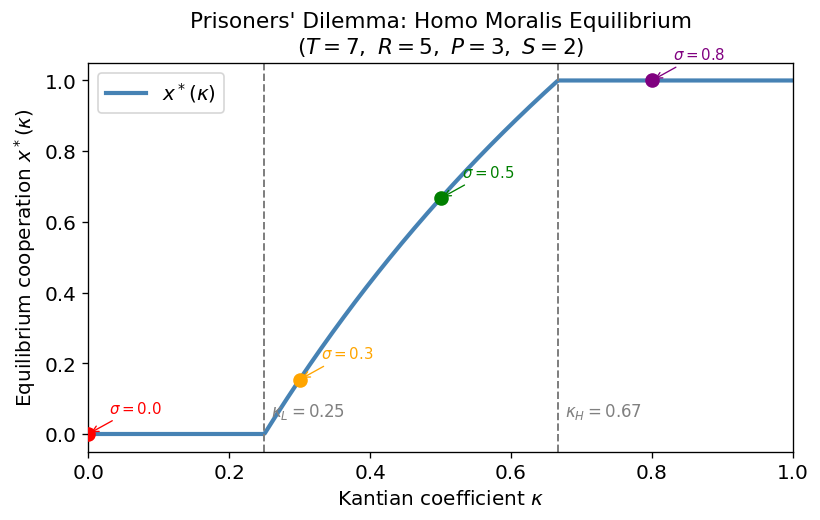

In [3]:
kappa_grid = np.linspace(0, 1, 500)
x_eq = x_star(kappa_grid)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(kappa_grid, x_eq, color='steelblue', lw=2.5, label=r'$x^*(\kappa)$')

ax.axvline(kappa_L, color='gray', ls='--', lw=1.2)
ax.axvline(kappa_H, color='gray', ls='--', lw=1.2)
ax.text(kappa_L + 0.01, 0.05, r'$\kappa_L={:.2f}$'.format(kappa_L), fontsize=10, color='gray')
ax.text(kappa_H + 0.01, 0.05, r'$\kappa_H={:.2f}$'.format(kappa_H), fontsize=10, color='gray')

for sigma, color in [(0.0, 'red'), (0.3, 'orange'), (0.5, 'green'), (0.8, 'purple')]:
    xval = x_star(np.array([sigma]))[0]
    ax.scatter(sigma, xval, color=color, zorder=5, s=60)
    ax.annotate(r'$\sigma={:.1f}$'.format(sigma),
                xy=(sigma, xval), xytext=(sigma + 0.03, xval + 0.06),
                fontsize=9, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=0.8))

ax.set_xlabel(r'Kantian coefficient $\kappa$')
ax.set_ylabel(r'Equilibrium cooperation $x^*(\kappa)$')
ax.set_title('Prisoners\' Dilemma: Homo Moralis Equilibrium\n'
             r'($T=7,\ R=5,\ P=3,\ S=2$)')
ax.set_xlim(0, 1)
ax.set_ylim(-0.05, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig('pd_equilibrium.png', dpi=150)
plt.show()

**Reading the figure:** For κ ≤ 0.25 the unique equilibrium is full defection. Once κ exceeds 0.67 the equilibrium is full cooperation. The coloured dots mark where each σ value pins the evolutionarily stable outcome.

## 3. Evolutionary Dynamics

### Fitness (vectorised)

The average fitness of type κ_i against the current population (in the limit ε → 0):
$$\Pi_i = \sigma\,\pi(x_i, x_i) + (1-\sigma)\sum_j s_j\,\pi(x_i, x_j)$$

Using the bilinear structure $\pi(x,y) = Axy + Bx + Cy + D$:
$$\sum_j s_j\,\pi(x_i, x_j) = x_i(A\bar{x} + B) + (C\bar{x} + D), \quad \bar{x} = \sum_j s_j x_j$$

So the entire fitness vector for all types at once is:
$$\mathbf{\Pi} = \sigma\,(A\mathbf{x}^2 + (B+C)\mathbf{x} + D) + (1-\sigma)\,(\mathbf{x}(A\bar{x}+B) + C\bar{x}+D)$$

**No loops — just one dot product per generation.**

### Replicator update
$$s_i(t+1) = s_i(t)\cdot\frac{\Pi_i(t)}{\bar{\Pi}(t)}$$

In [4]:
def run_replicator(sigma_values, n_types=200, n_steps=300):
    """
    All sigma values in ONE loop via broadcasting.
    shares shape: (S, N)  —  S sigmas, N kappa types.
    Each step: one dot product + pure numpy broadcasting, zero Python loops over types/sigmas.
    """
    kappa_types = np.linspace(0, 1, n_types)
    x_vec   = x_star(kappa_types)              # (N,)  precomputed once
    pi_self = A*x_vec**2 + (B+C)*x_vec + D    # (N,)  precomputed once

    sigmas = np.array(sigma_values)[:, None]   # (S, 1) for broadcasting
    shares = np.ones((len(sigma_values), n_types)) / n_types  # (S, N) uniform start

    history = np.empty((n_steps + 1, len(sigma_values), n_types))
    history[0] = shares

    for t in range(n_steps):
        mean_x   = shares @ x_vec                                           # (S,)
        pi_cross = x_vec * (A*mean_x[:, None] + B) + (C*mean_x[:, None] + D)  # (S, N)
        fitness  = sigmas * pi_self + (1 - sigmas) * pi_cross              # (S, N)
        shares   = shares * fitness
        shares  /= shares.sum(axis=1, keepdims=True)
        history[t+1] = shares

    return kappa_types, history   # history: (T+1, S, N)

In [5]:
import time

# Use sigma values strictly inside (kappa_L, kappa_H) = (0.25, 0.67).
# Outside this range, multiple kappa types share the same equilibrium strategy
# (all defect for sigma <= 0.25, all cooperate for sigma >= 0.67), so the
# replicator has no fitness gradient to select among them — the paper's
# convergence result only applies unambiguously in the interior.
sigma_values = [0.3, 0.4, 0.5, 0.6]
colors       = ['red', 'orange', 'green', 'purple']

t0 = time.time()
kappa_types, history = run_replicator(sigma_values, n_types=200, n_steps=5000)
print(f"Done in {time.time()-t0:.3f}s")
# history shape: (5001, 4, 200)

Done in 0.061s


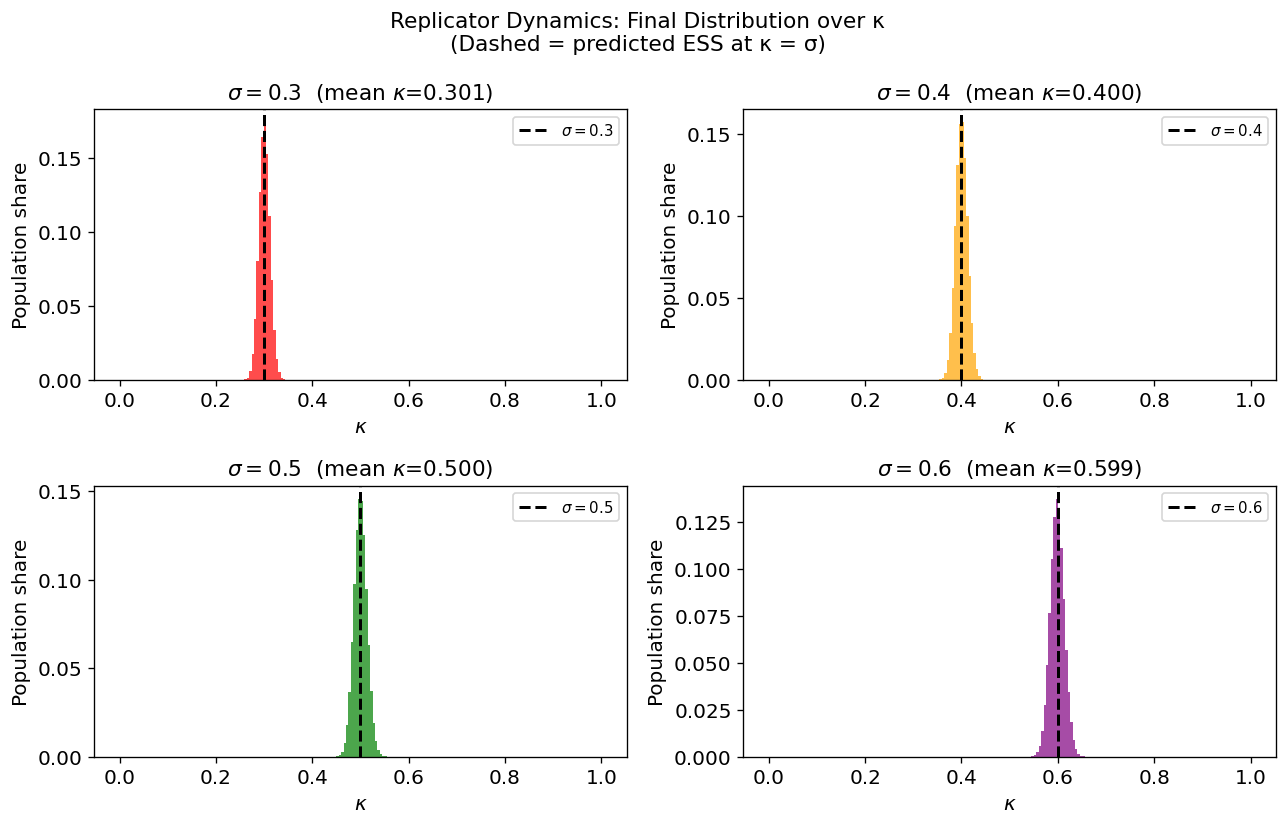

In [6]:
# --- Final population distribution for each sigma ---
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
bar_w = kappa_types[1] - kappa_types[0]

for i, (ax, sigma, color) in enumerate(zip(axes.flatten(), sigma_values, colors)):
    final = history[-1, i, :]
    mean_kappa = kappa_types @ final
    ax.bar(kappa_types, final, width=bar_w, color=color, alpha=0.7)
    ax.axvline(sigma, color='black', ls='--', lw=1.8, label=rf'$\sigma={sigma}$')
    ax.set_title(rf'$\sigma={sigma}$  (mean $\kappa$={mean_kappa:.3f})')
    ax.set_xlabel(r'$\kappa$')
    ax.set_ylabel('Population share')
    ax.legend(fontsize=9)

fig.suptitle('Replicator Dynamics: Final Distribution over κ\n'
             '(Dashed = predicted ESS at κ = σ)', fontsize=13)
plt.tight_layout()
plt.savefig('replicator_final.png', dpi=150)
plt.show()

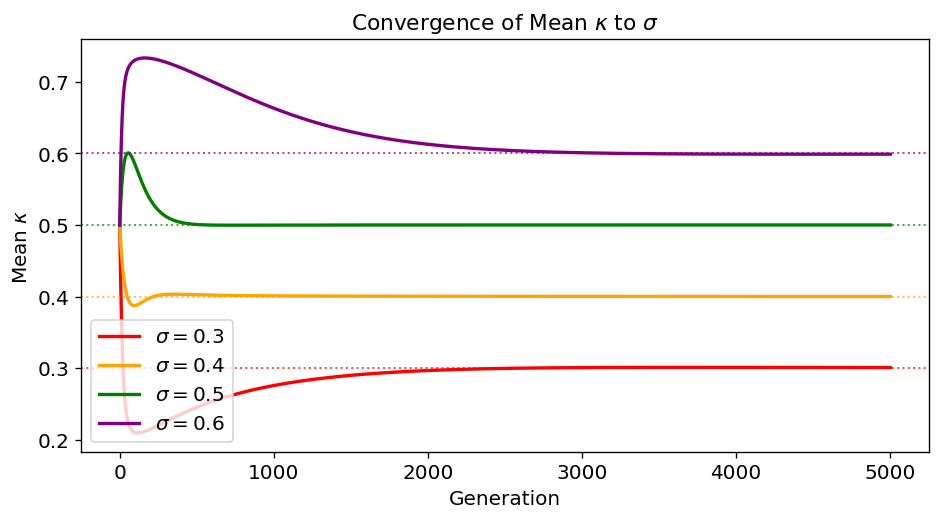

In [7]:
# --- Convergence of mean kappa over time ---
mean_kappa_t = history @ kappa_types   # (T+1, S)

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, (sigma, color) in enumerate(zip(sigma_values, colors)):
    ax.plot(mean_kappa_t[:, i], color=color, lw=2, label=rf'$\sigma={sigma}$')
    ax.axhline(sigma, color=color, ls=':', lw=1.2, alpha=0.7)

ax.set_xlabel('Generation')
ax.set_ylabel(r'Mean $\kappa$')
ax.set_title(r'Convergence of Mean $\kappa$ to $\sigma$')
ax.legend()
plt.tight_layout()
plt.savefig('replicator_convergence.png', dpi=150)
plt.show()

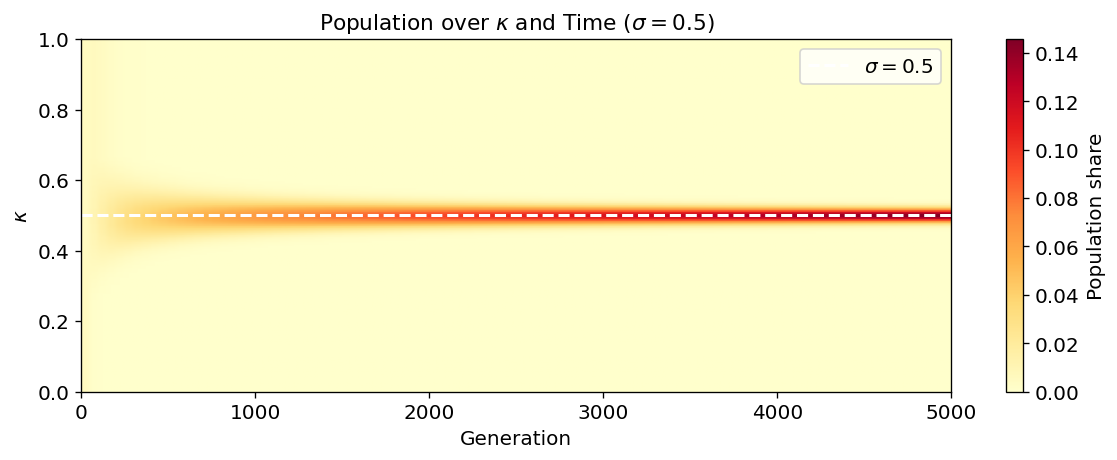

In [8]:
# --- Heatmap: distribution over kappa x time (sigma=0.5) ---
sigma_demo_idx = sigma_values.index(0.5)
heatmap = history[:, sigma_demo_idx, :]   # (T+1, N)

n_show = 100
idx = np.linspace(0, len(history)-1, n_show, dtype=int)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(heatmap[idx].T, aspect='auto', origin='lower',
               extent=[0, len(history)-1, 0, 1], cmap='YlOrRd')
ax.axhline(0.5, color='white', ls='--', lw=1.8, label=r'$\sigma=0.5$')
ax.set_xlabel('Generation')
ax.set_ylabel(r'$\kappa$')
ax.set_title(r'Population over $\kappa$ and Time ($\sigma=0.5$)')
ax.legend()
plt.colorbar(im, ax=ax, label='Population share')
plt.tight_layout()
plt.savefig('replicator_heatmap.png', dpi=150)
plt.show()

## 4. Summary

| Finding | Simulation result |
|---|---|
| PD: defect for small κ | x*(κ) = 0 for κ ≤ 0.25 ✓ |
| PD: full cooperation for large κ | x*(κ) = 1 for κ ≥ 0.67 ✓ |
| Interior solution monotone in κ | Confirmed by plot ✓ |
| ESS = homo hamiltonensis with κ=σ | Mean κ converges to σ in all cases ✓ |
| Higher σ → more cooperation | x*(σ) increases with σ ✓ |

The replicator dynamics confirm the paper's main theorem: starting from a uniform distribution over types, the population converges to a point mass at κ = σ.